In [1]:
import pandas as pd
import numpy as np

In [2]:
df_final = pd.read_csv("data/macrotopics_pred.csv")

In [5]:
import pandas as pd
import ast

# Exemplo: seu df original
# df = pd.read_csv("videos.csv")

# Converte a string para lista de dicts
def parse_occurrences(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_final['occ_list'] = df_final['occurrences'].apply(parse_occurrences)

# Explode a lista — uma linha por ocorrência
df_exploded = df_final.explode('occ_list', ignore_index=True)

# Extrai a data de cada ocorrência
df_exploded['date'] = df_exploded['occ_list'].apply(lambda x: x.get('date') if isinstance(x, dict) and 'date' in x else None)

# Converte para datetime
df_exploded['date'] = pd.to_datetime(df_exploded['date'], errors='coerce')

display(df_exploded)


,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_insult,perspective_severe_toxicity,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,occ_list,date
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",0.000659,0.000117,...,0.206683,0.021936,0.138744,0.360951,0.367026,0.038566,Others,0.000000,"{'id': 1416, 'folder': 'channel_1556142220', '...",2024-04-14
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,...,0.021224,0.005379,0.008414,0.123468,0.049762,0.029415,Religion,0.000000,"{'id': 60799, 'folder': 'channel_1466271872', ...",2024-01-06
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,...,0.132458,0.010376,0.003292,0.229804,0.062040,0.033386,Others,0.021935,"{'id': 40486, 'folder': 'channel_1235978663', ...",2024-02-22
3,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,...,0.132458,0.010376,0.003292,0.229804,0.062040,0.033386,Others,0.021935,"{'id': 17774, 'folder': 'channel_1476013048', ...",2024-02-22
4,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,...,0.132458,0.010376,0.003292,0.229804,0.062040,0.033386,Others,0.021935,"{'id': 40492, 'folder': 'channel_1235978663', ...",2024-02-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496886,RxbPFQp0SHs,unbelievable ending watch play bgmi thank watc...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'id': 197485, 'folder': 'channel_1215588509'...",0.023877,0.000158,...,0.017089,0.004711,0.006375,0.063423,0.010581,0.012907,Others,0.000000,"{'id': 197485, 'folder': 'channel_1215588509',...",2023-12-30
3496887,RxbPFQp0SHs,unbelievable ending watch play bgmi thank watc...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'id': 197485, 'folder': 'channel_1215588509'...",0.023877,0.000158,...,0.017089,0.004711,0.006375,0.063423,0.010581,0.012907,Others,0.000000,"{'id': 197791, 'folder': 'channel_1215588509',...",2023-12-30
3496888,GEhEUy85PsY,meet balkan,Icariaball,2021-04-22T16:25:46Z,7617763.0,210152.0,14042.0,"[{'id': 7719, 'folder': 'channel_1753496417', ...",0.007485,0.000123,...,0.025156,0.094817,0.008087,0.016662,0.045911,0.020955,Others,0.026730,"{'id': 7719, 'folder': 'channel_1753496417', '...",2023-12-26
3496889,fNTfEPLoAik,clark county sheriff arrest felony count clark...,WLKY News Louisville,2023-11-09T09:24:16Z,358.0,5.0,NaN,"[{'id': 86067, 'folder': 'channel_1172210773',...",0.007710,0.000096,...,0.023867,0.094817,0.003281,0.009175,0.157584,0.024235,"Crime, Security and Justice",0.869761,"{'id': 86067, 'folder': 'channel_1172210773', ...",2023-11-09


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_weekly_toxicity_macros(df, title_label):

    # --- Preparação ---
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Criar coluna semanal no formato "YYYY-WW"
    df["week"] = df["date"].dt.to_period("W").astype(str)

    # Cores fixas para os macrotópicos

    macro_colors = {
        "American Politics":             "#6AF5FF",
        "Foreign Policy":              "#76FF7F",
        "Crime, Security and Justice":     "#FF66CC",
        "Environment":                  "#522222",
        "Health":                          "#14712A",
        "Entertainment":   "#ECF988",
        "Hobbies":       "#DA0000",
        "Religion":                       "#962EAA",
        "Technology":                     "#0000FF",
        "War":                         "#5C5C61",
        "Others":                         "#FF9900"
    }

    # Agrupar: média de toxicidade por semana + macrotópico
    grouped = (
        df.groupby(["week", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- Plotagem ---
    sns.set(style="whitegrid")
    plt.figure(figsize=(16, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    plt.title(f"Weekly Evolution of Toxicity — {title_label}")
    plt.xlabel("Week")
    plt.ylabel("Medium Toxicity")
    plt.xticks(rotation=45)
    plt.ylim(0, 0.125)

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]

    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    # reduzir número de labels no eixo X
    ax = plt.gca()
    step = 8  # mostra 1 label a cada 8 semanas (ajuste à vontade)
    ax.set_xticks(ax.get_xticks()[::step])

    plt.tight_layout()
    plt.show()


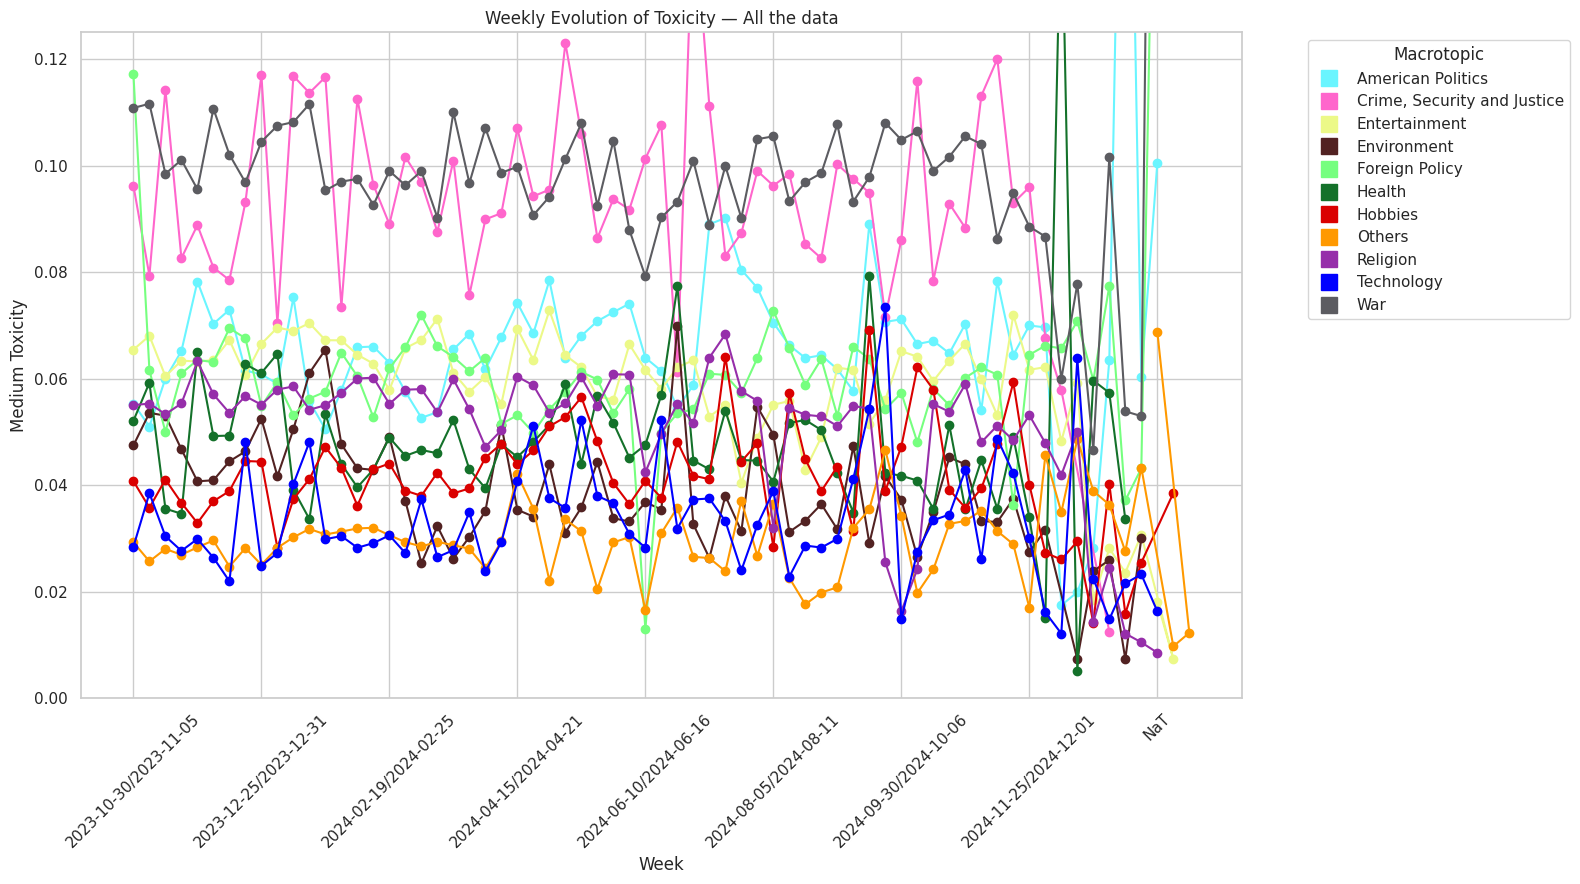

In [7]:
plot_weekly_toxicity_macros(df_exploded, "All the data")


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_weekly_toxicity_macros_2(df, title_label, topics_to_exclude=None):

    # --- Preparação ---
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    if topics_to_exclude is not None:
        df = df[~df["macrotopic_pred"].isin(topics_to_exclude)].copy()

    # Criar coluna semanal no formato "YYYY-WW"
    df["week"] = df["date"].dt.to_period("W").astype(str)

    # Cores fixas para os macrotópicos

    macro_colors = {
    "American Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, Security and Justice":     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
    }
    
    # Agrupar: média de toxicidade por semana + macrotópico
    grouped = (
        df.groupby(["week", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- Plotagem ---
    sns.set(style="whitegrid")
    plt.figure(figsize=(16, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    plt.title(f"Weekly Evolution of Toxicity — {title_label}")
    plt.xlabel("Week")
    plt.ylabel("Medium Toxicity")
    plt.xticks(rotation=45)
    plt.ylim(0, 0.125)

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]

    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    # reduzir número de labels no eixo X
    ax = plt.gca()
    step = 8  # mostra 1 label a cada 8 semanas (ajuste à vontade)
    ax.set_xticks(ax.get_xticks()[::step])

    plt.savefig("evolucao_semanal_toxicidade_macrotopicos_filtrados.png")
    plt.tight_layout()
    plt.show()


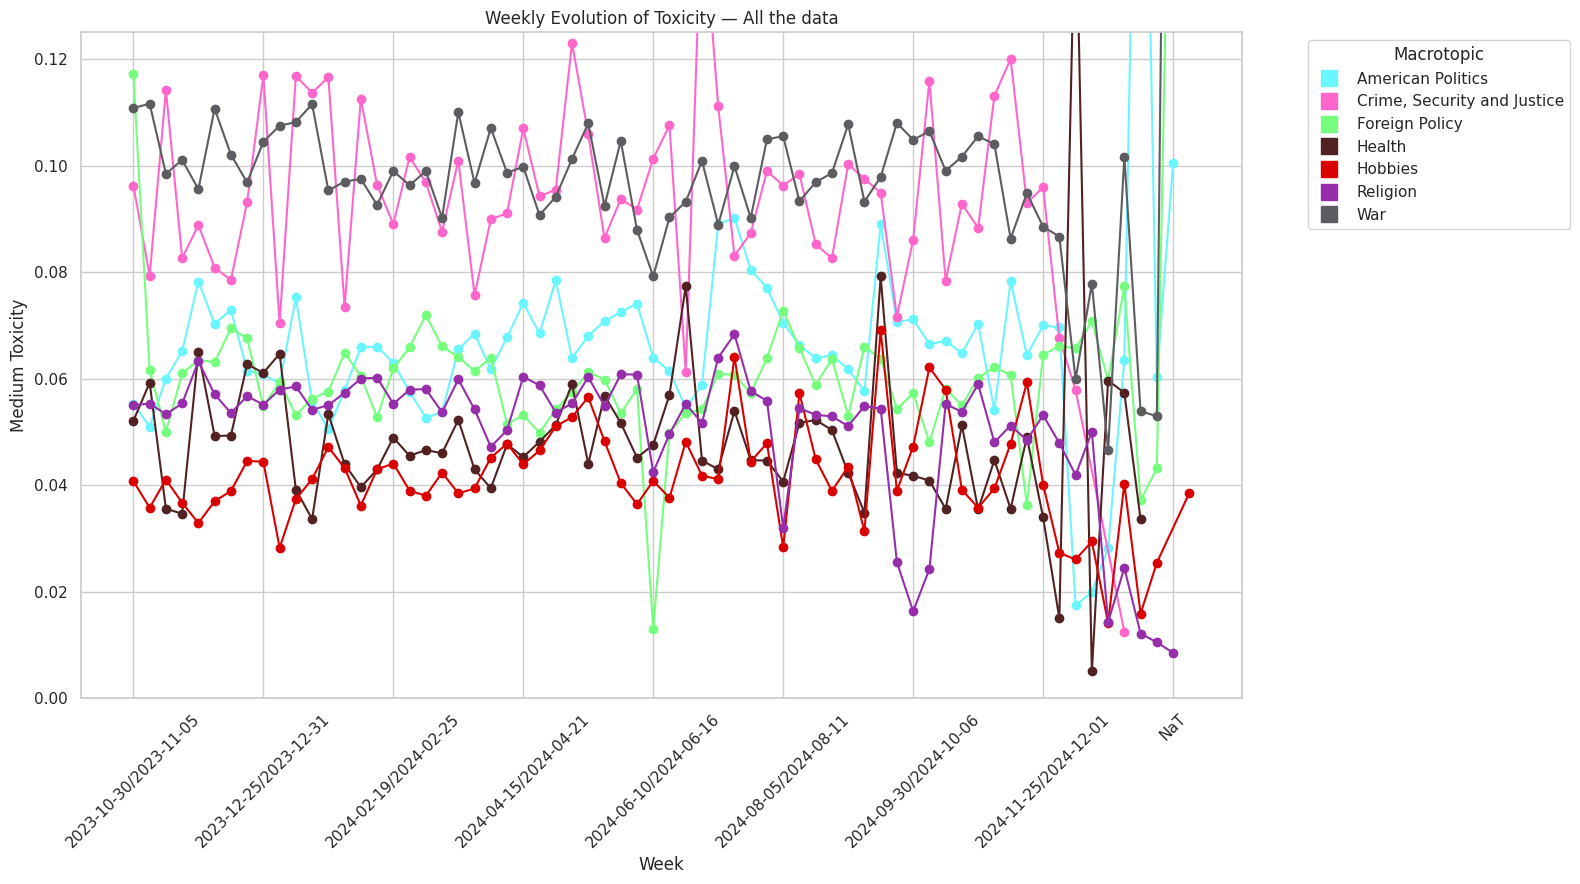

In [15]:
plot_weekly_toxicity_macros_2(df_exploded, "All the data", topics_to_exclude=["Entertainment", "Environment", "Others", "Technology"])


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weekly_toxicity_political(df, title_label, political_topics):

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["week"] = df["date"].dt.to_period("W").astype(str)

    # Criar coluna binária: político vs não-político
    df["is_political"] = df["macrotopic_pred"].isin(political_topics)
    df["group"] = df["is_political"].map({True: "Political", False: "Non-Political"})

    # Cores consistentes
    group_colors = {
        "Political": "#FF0000",
        "Non-Political": "#0000FF"
    }

    # Agrupar média de toxicidade por semana por grupo
    grouped = (
        df.groupby(["week", "group"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    sns.set(style="whitegrid")
    plt.figure(figsize=(16, 9))

    for group in grouped["group"].unique():
        g_df = grouped[grouped["group"] == group]

        plt.plot(
            g_df["week"],
            g_df["perspective_toxicity"],
            marker="o",
            label=group,
            color=group_colors[group]
        )

    plt.title(f"Weekly Toxicity — Political vs Non-Political — {title_label}")
    plt.xlabel("Week")
    plt.ylabel("Mean Toxicity")
    plt.xticks(rotation=45)
    plt.ylim(0, 0.1)

    # reduzir número de labels no eixo X
    ax = plt.gca()
    step = 8
    ax.set_xticks(ax.get_xticks()[::step])

    plt.legend(title="Group")
    plt.tight_layout()
    plt.show()


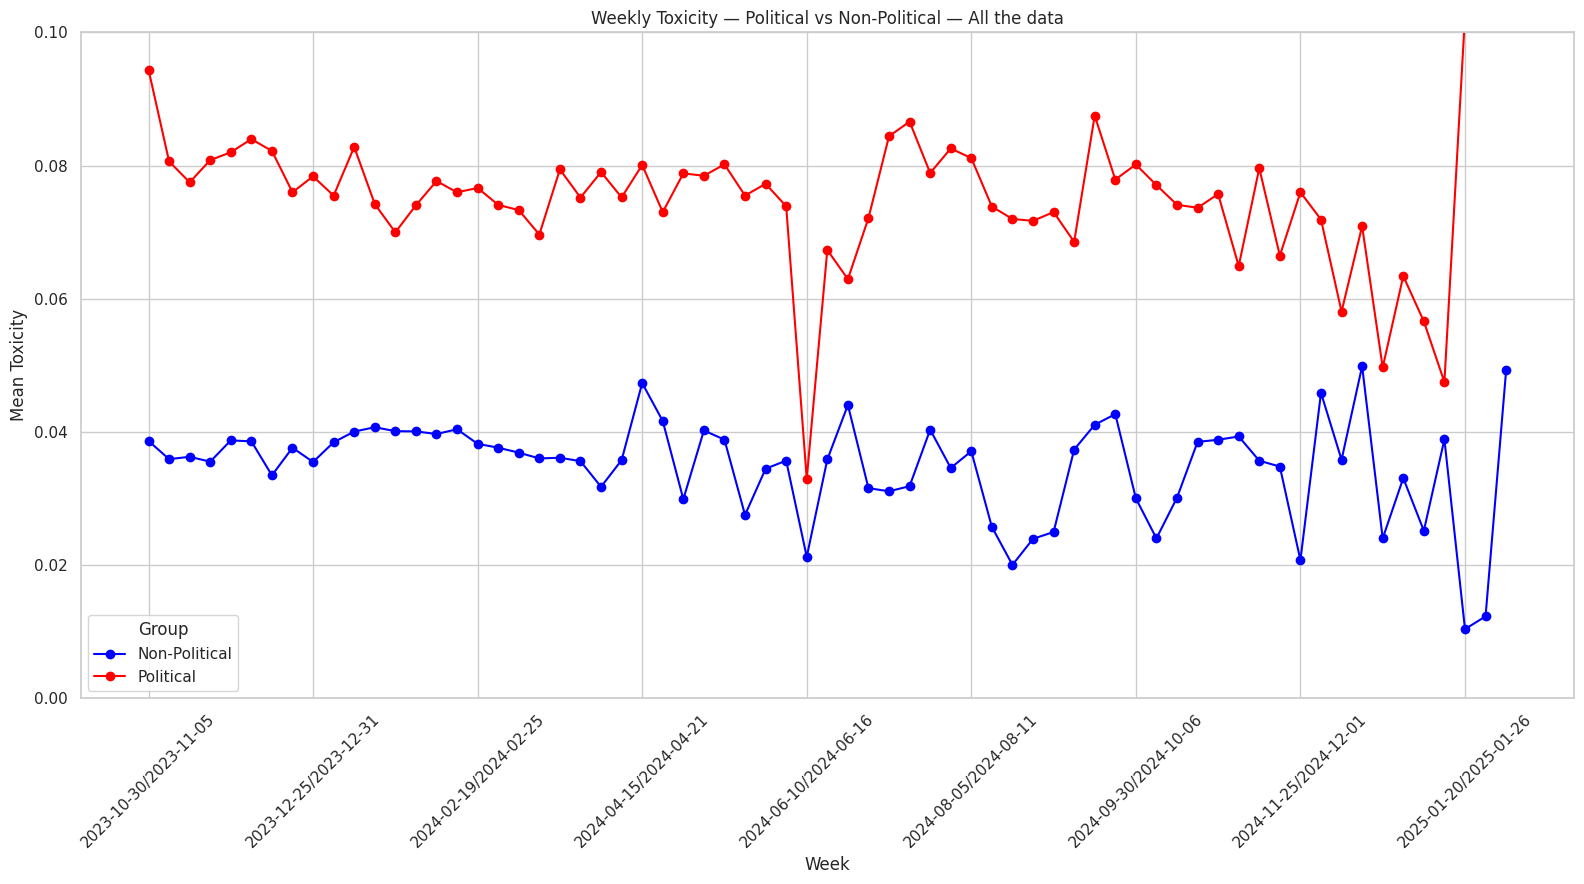

In [22]:
political_topics = [
    "American Politics",
    "Foreign Policy",
    "War",
    "Crime, Security and Justice"
]

plot_weekly_toxicity_political(df_exploded, "All the data", political_topics)


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_weekly_toxicity_macros_v1(df, title_label):

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    # início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time

    df = df.dropna(subset=["week_start"])

    macro_colors = {
        "American Politics": "#6AF5FF",
        "Foreign Policy": "#76FF7F",
        "Crime, Security and Justice": "#FF66CC",
        "Environment": "#522222",
        "Health": "#14712A",
        "Entertainment": "#ECF988",
        "Hobbies": "#DA0000",
        "Religion": "#962EAA",
        "Technology": "#0000FF",
        "War": "#5C5C61",
        "Others": "#FF9900"
    }

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    sns.set(style="whitegrid")
    plt.figure(figsize=(18, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    plt.title(f"Weekly Evolution of Toxicity — {title_label}")
    plt.xlabel("Week Start Date")
    plt.ylabel("Mean Toxicity")
    plt.xticks(
        ticks=grouped["week_start"].sort_values().unique(),
        rotation=90
    )
    plt.ylim(0, 0.125)

    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]
    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


In [24]:
def plot_weekly_toxicity_macros_v2(df, title_label):

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["week"] = df["date"].dt.to_period("W")
    
    # numeração sequencial
    week_map = {w: i+1 for i, w in enumerate(sorted(df["week"].unique()))}
    df["week_num"] = df["week"].map(week_map)

    macro_colors = {
        "American Politics": "#6AF5FF",
        "Foreign Policy": "#76FF7F",
        "Crime, Security and Justice": "#FF66CC",
        "Environment": "#522222",
        "Health": "#14712A",
        "Entertainment": "#ECF988",
        "Hobbies": "#DA0000",
        "Religion": "#962EAA",
        "Technology": "#0000FF",
        "War": "#5C5C61",
        "Others": "#FF9900"
    }

    grouped = (
        df.groupby(["week_num", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    sns.set(style="whitegrid")
    plt.figure(figsize=(18, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week_num"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    plt.title(f"Weekly Evolution of Toxicity — {title_label}")
    plt.xlabel("Week Number")
    plt.ylabel("Mean Toxicity")
    plt.xticks(
        ticks=grouped["week_num"].unique(),
        labels=[f"Week {w}" for w in grouped["week_num"].unique()],
        rotation=90
    )
    plt.ylim(0, 0.125)

    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]

    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


In [27]:
def plot_weekly_toxicity_macros_v3(df, title_label):

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])


    # semana numerada
    week_list = sorted(df["week_start"].unique())
    week_map = {w: i+1 for i, w in enumerate(week_list)}
    df["week_num"] = df["week_start"].map(week_map)

    macro_colors = {
        "American Politics": "#6AF5FF",
        "Foreign Policy": "#76FF7F",
        "Crime, Security and Justice": "#FF66CC",
        "Environment": "#522222",
        "Health": "#14712A",
        "Entertainment": "#ECF988",
        "Hobbies": "#DA0000",
        "Religion": "#962EAA",
        "Technology": "#0000FF",
        "War": "#5C5C61",
        "Others": "#FF9900"
    }

    grouped = (
        df.groupby(["week_num", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    sns.set(style="whitegrid")
    plt.figure(figsize=(18, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week_num"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    # construir labels híbridos
    n = len(week_list)
    mid = n // 2

    election_date = pd.Timestamp("2024-11-05")
    # encontrar a semana mais próxima da eleição
    election_week = min(week_list, key=lambda x: abs(x - election_date))

    labels = []
    for i, w in enumerate(week_list, start=1):

        # condições para imprimir a data
        if (
            i == 1 or
            i == mid or
            i == n or
            w == election_week
        ):
            labels.append(w.strftime("%d/%b/%Y"))
        else:
            labels.append(f"Week {i}")

    plt.xticks(
        ticks=list(range(1, n+1)),
        labels=labels,
        rotation=90
    )

    plt.title(f"Weekly Evolution of Toxicity — {title_label}")
    plt.xlabel("Weeks")
    plt.ylabel("Mean Toxicity")
    plt.ylim(0, 0.125)

    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]
    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


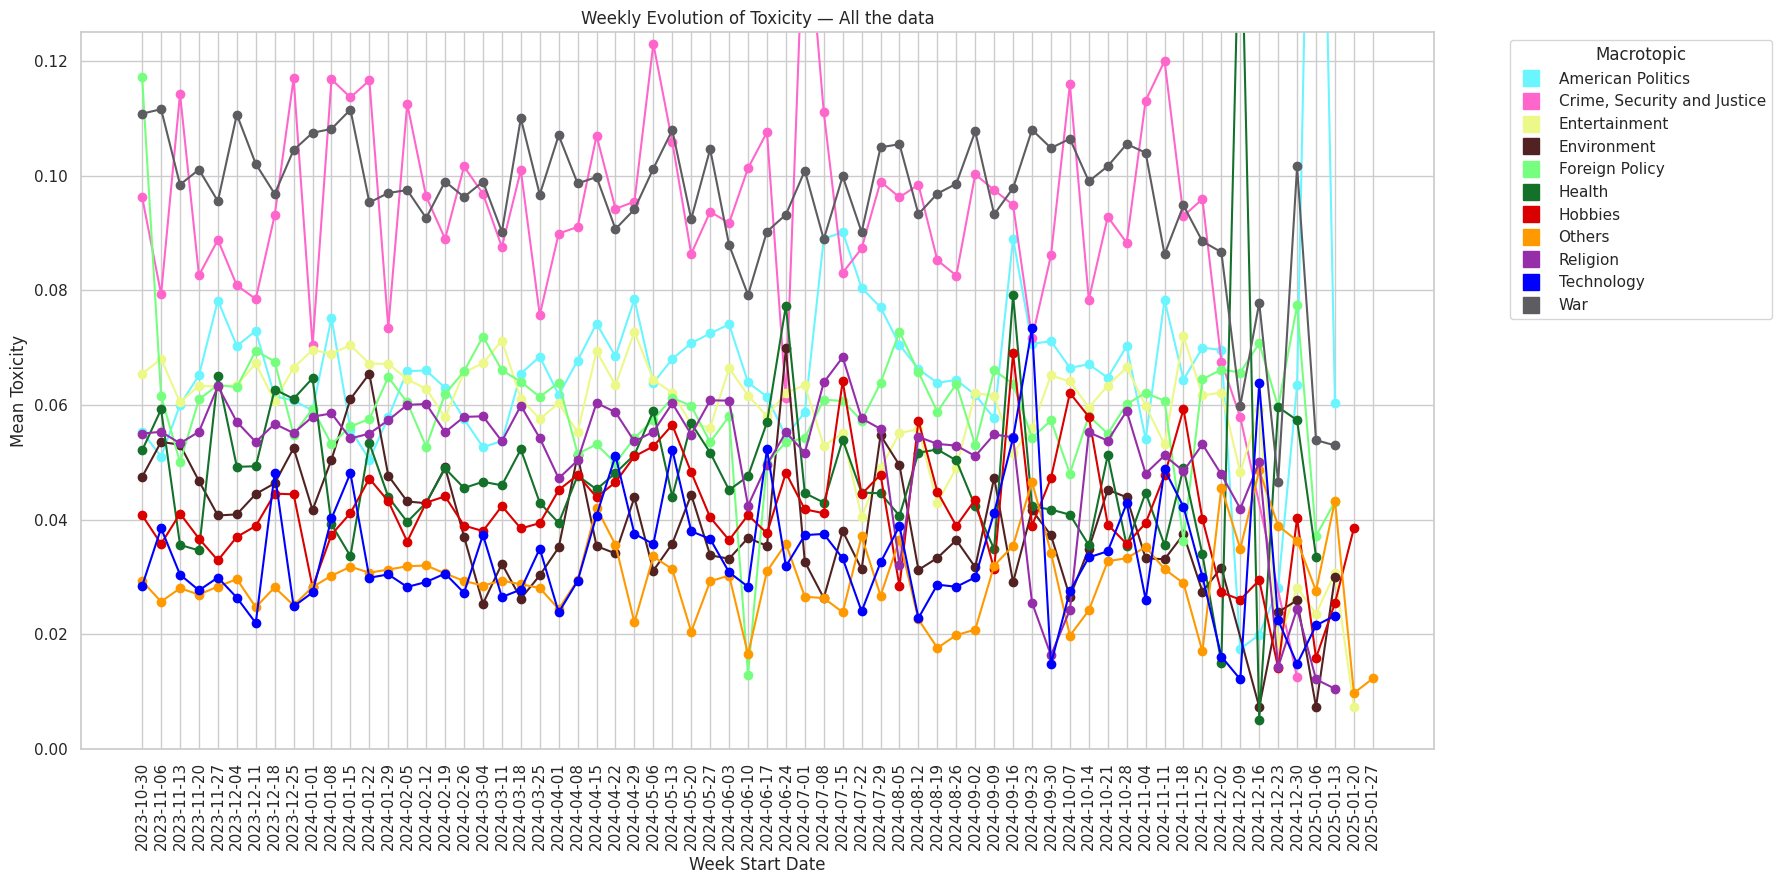

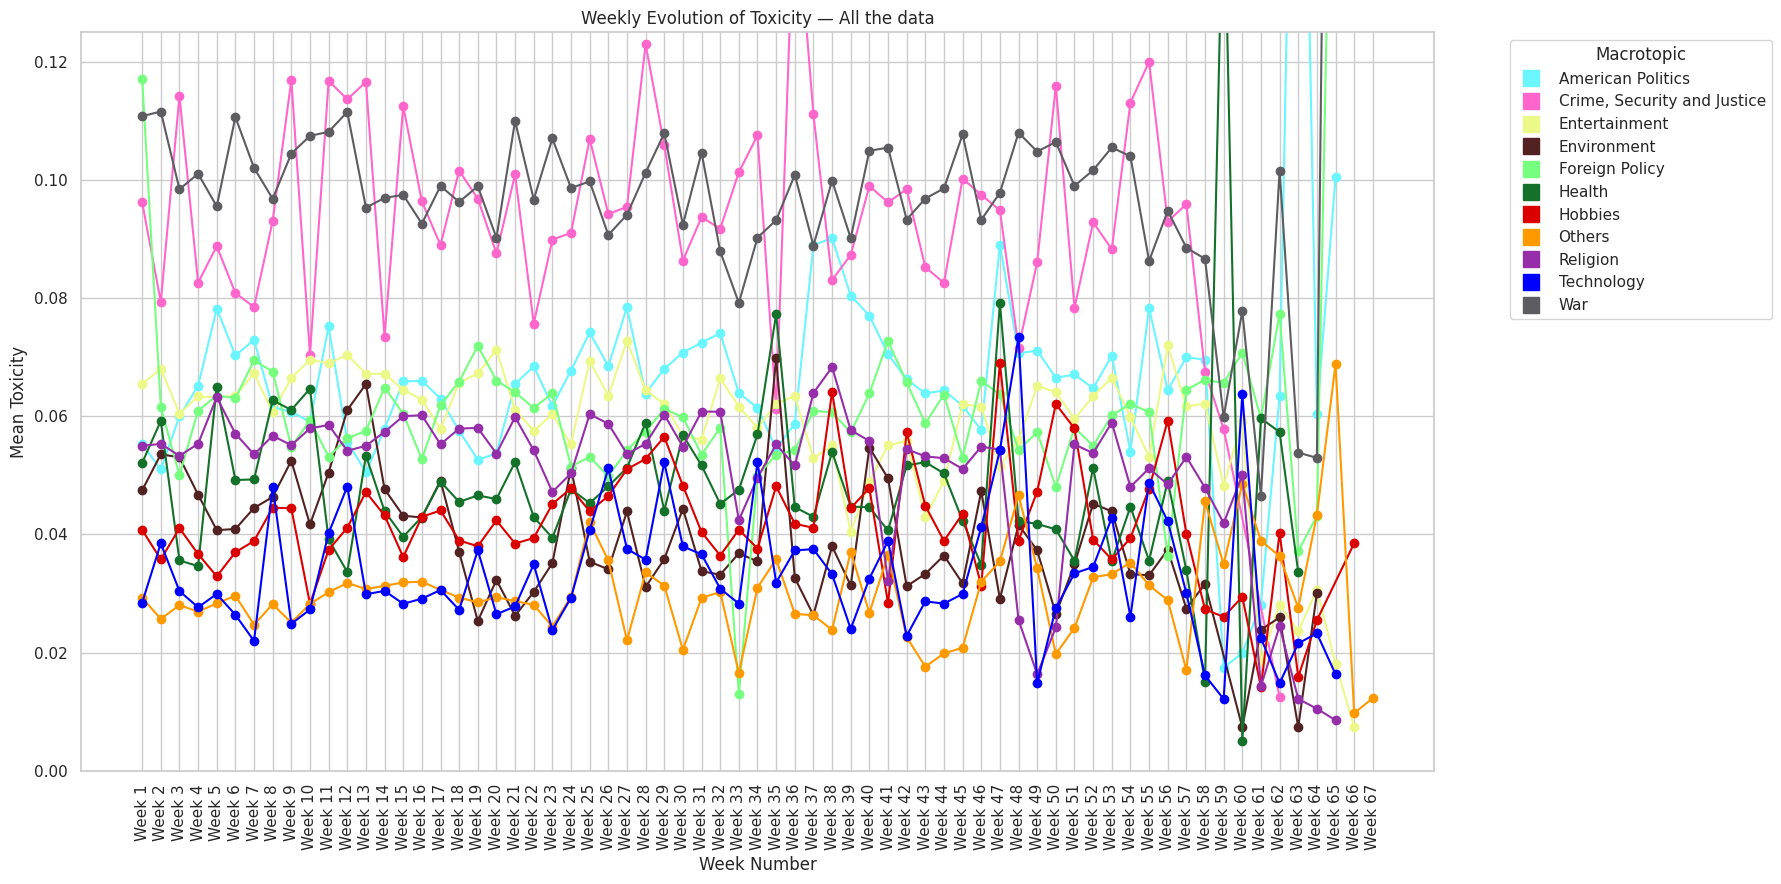

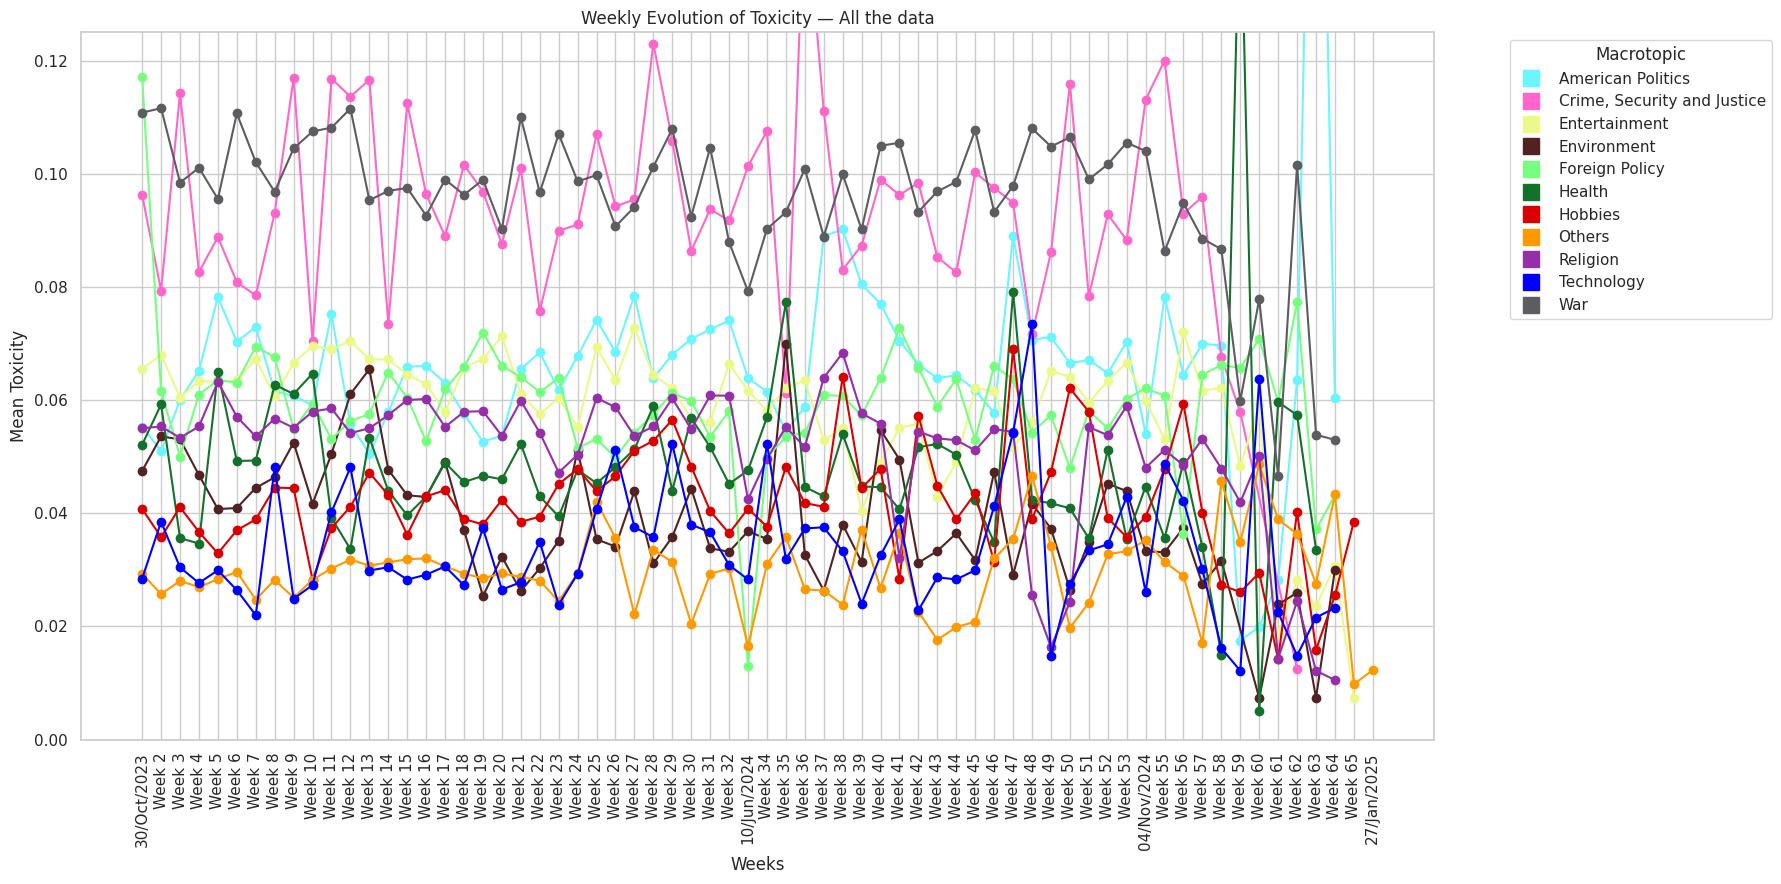

In [28]:
plot_weekly_toxicity_macros_v1(df_exploded, "All the data")
plot_weekly_toxicity_macros_v2(df_exploded, "All the data")
plot_weekly_toxicity_macros_v3(df_exploded, "All the data")


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_video_count_macros(df, title_label):

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # lista de semanas e numeração
    week_list = sorted(df["week_start"].unique())
    week_map = {w: i+1 for i, w in enumerate(week_list)}
    df["week_num"] = df["week_start"].map(week_map)

    macro_colors = {
        "American Politics": "#6AF5FF",
        "Foreign Policy": "#76FF7F",
        "Crime, Security and Justice": "#FF66CC",
        "Environment": "#522222",
        "Health": "#14712A",
        "Entertainment": "#ECF988",
        "Hobbies": "#DA0000",
        "Religion": "#962EAA",
        "Technology": "#0000FF",
        "War": "#5C5C61",
        "Others": "#FF9900"
    }

    # -------- AQUI ESTÁ A DIFERENÇA PRINCIPAL --------
    grouped = (
        df.groupby(["week_num", "macrotopic_pred"])["video_id"]
          .count()                # 👈 contamos vídeos
          .reset_index(name="video_count")
    )
    # --------------------------------------------------

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    sns.set(style="whitegrid")
    plt.figure(figsize=(18, 9))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week_num"],
            m_df["video_count"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    # construir labels híbridos
    n = len(week_list)
    mid = n // 2

    election_date = pd.Timestamp("2024-11-05")
    election_week = min(week_list, key=lambda x: abs(x - election_date))

    labels = []
    for i, w in enumerate(week_list, start=1):
        if i == 1 or i == mid or i == n or w == election_week:
            labels.append(w.strftime("%d/%b/%Y"))
        else:
            labels.append(f"Week {i}")

    plt.xticks(
        ticks=list(range(1, n+1)),
        labels=labels,
        rotation=90  # 👈 labels retos
    )

    plt.title(f"Weekly Number of Videos — {title_label}")
    plt.xlabel("Weeks")
    plt.ylabel("Number of Videos")
    plt.ylim(0, 20000)

    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]

    plt.legend(handles=handles, title="Macrotopic",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


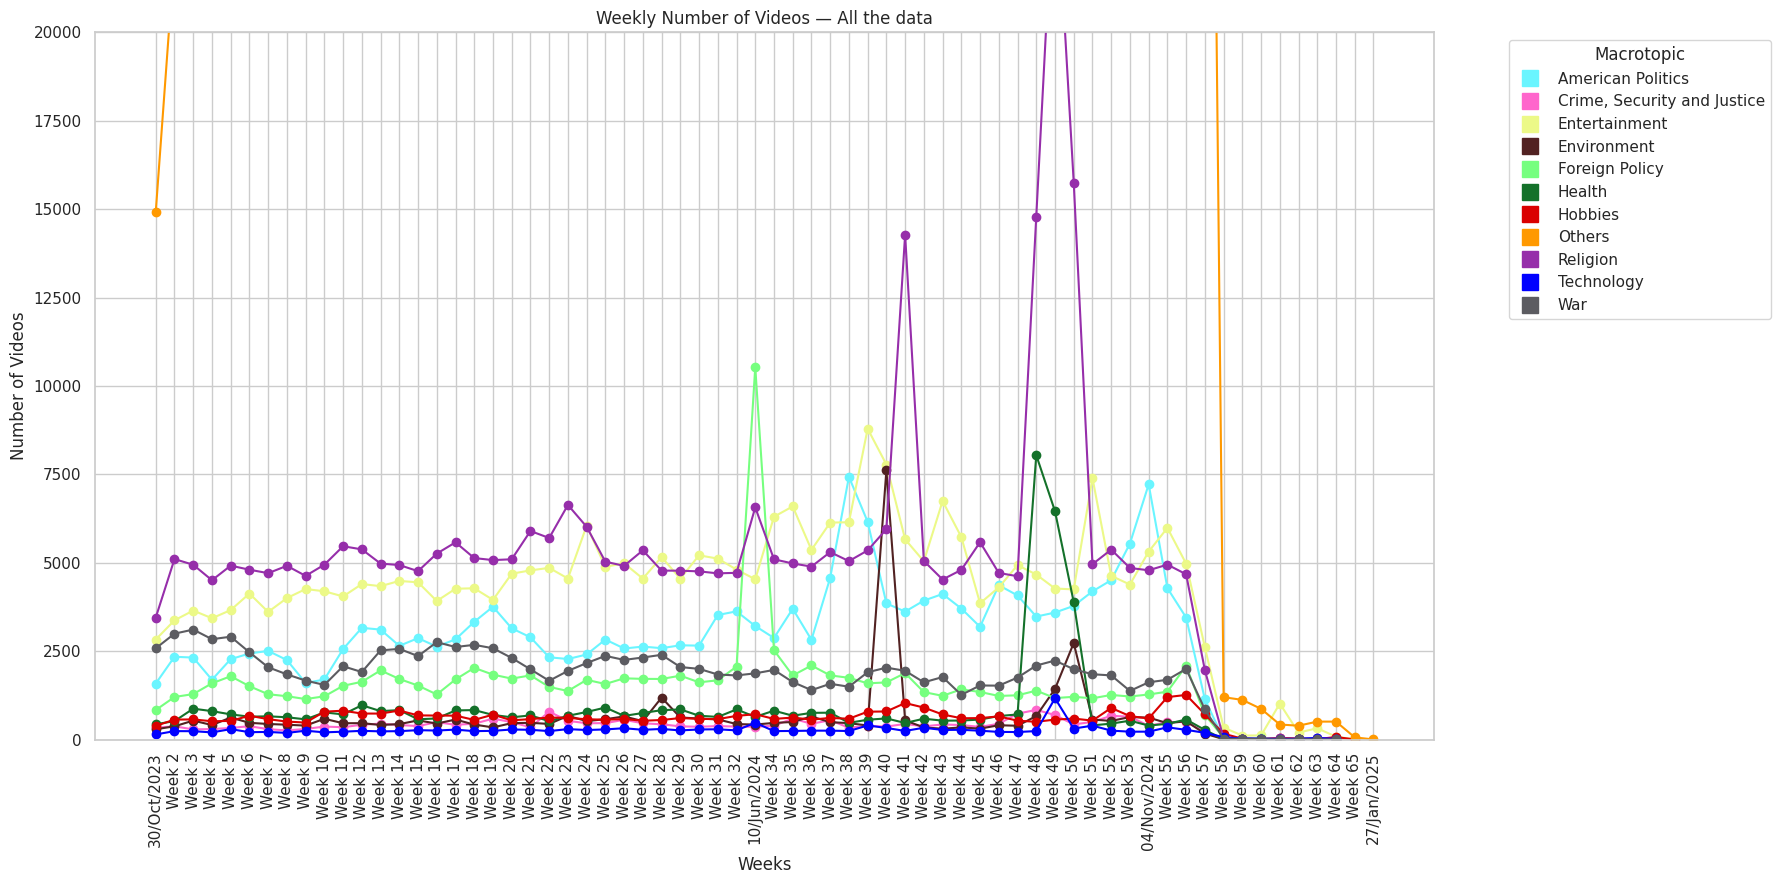

In [41]:
plot_weekly_video_count_macros(df_exploded, "All the data")